# retrofitting pre-built network
This is a general idea without validation!  

**pre-built network** means that we use a network that was created with the standard pypsa-eur workflow. In this case standard workflow refers to creating a network with the rule *solve_elec_network* with whatever configuration (config.yaml) you choose.  
(e.g.: snakemake -call solve_elec_networks --configfile ../config/FR_2020-08_6_clusters_2030.yaml --latency-wait 300 --cores all)  
The resulting .nc-file is then used in this retrofitting approach.

### loading network

In [100]:
import pypsa 
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x2535edd5590>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x2535edd56d0>,
  'Line': <matplotlib.collections.LineCollection at 0x2535edd5810>},
 'flows': {}}

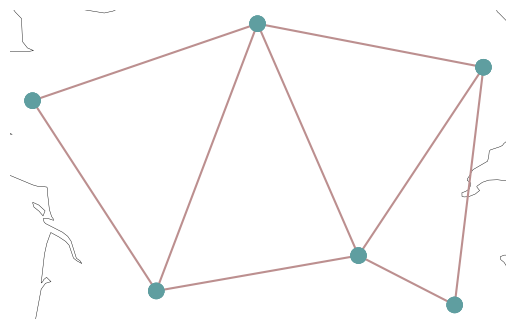

In [101]:
n = pypsa.Network("../results/FR_2020-08_6_clusters_2030/networks/base_s_6_elec_.nc")
n.plot()

### hydro and PHS static data

In [102]:
print(n.storage_units.keys())
print(n.storage_units_t.keys())

Index(['bus', 'control', 'type', 'p_nom', 'p_nom_mod', 'p_nom_extendable',
       'p_nom_min', 'p_nom_max', 'p_nom_set', 'p_min_pu', 'p_max_pu', 'p_set',
       'q_set', 'p_dispatch_set', 'p_store_set', 'sign', 'carrier',
       'spill_cost', 'marginal_cost', 'marginal_cost_quadratic',
       'marginal_cost_storage', 'capital_cost', 'active', 'build_year',
       'lifetime', 'state_of_charge_initial',
       'state_of_charge_initial_per_period', 'state_of_charge_set',
       'cyclic_state_of_charge', 'cyclic_state_of_charge_per_period',
       'max_hours', 'efficiency_store', 'efficiency_dispatch', 'standing_loss',
       'inflow', 'p_nom_opt'],
      dtype='object')
dict_keys(['p_min_pu', 'p_max_pu', 'p_set', 'q_set', 'p_dispatch_set', 'p_store_set', 'spill_cost', 'marginal_cost', 'marginal_cost_quadratic', 'marginal_cost_storage', 'state_of_charge_set', 'efficiency_store', 'efficiency_dispatch', 'standing_loss', 'inflow', 'p', 'p_dispatch', 'p_store', 'q', 'state_of_charge', 'spill',

In [103]:
n.storage_units.T

name,FR0 0 PHS,FR0 3 PHS,FR0 4 PHS,FR0 5 PHS,FR0 0 hydro,FR0 2 hydro,FR0 4 hydro,FR0 5 hydro
bus,FR0 0,FR0 3,FR0 4,FR0 5,FR0 0,FR0 2,FR0 4,FR0 5
control,PQ,PQ,PQ,PQ,PQ,PQ,PQ,PQ
type,,,,,,,,
p_nom,3660.0,240.0,1368.0,808.0,4629.101911,1866.196178,1694.152866,424.0
p_nom_mod,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_nom_extendable,False,False,False,False,False,False,False,False
p_nom_min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_nom_max,inf,inf,inf,inf,inf,inf,inf,inf
p_nom_set,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_min_pu,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0


In [104]:
# installed hydro capacities
hydro_capacities = n.storage_units[n.storage_units.carrier == "hydro"].copy()
hydro_capacities["storage_capacity"] = hydro_capacities.p_nom * hydro_capacities.max_hours
# list of relevant information
hydro_capacities[["bus", "carrier", "p_nom", "p_nom_extendable", "p_nom_opt", "p_min_pu", "p_max_pu",
                   "storage_capacity", "max_hours", "efficiency_store", "efficiency_dispatch"]].T

name,FR0 0 hydro,FR0 2 hydro,FR0 4 hydro,FR0 5 hydro
bus,FR0 0,FR0 2,FR0 4,FR0 5
carrier,hydro,hydro,hydro,hydro
p_nom,4629.101911,1866.196178,1694.152866,424.0
p_nom_extendable,False,False,False,False
p_nom_opt,4629.101911,1866.196178,1694.152866,424.0
p_min_pu,0.0,0.0,0.0,0.0
p_max_pu,1.0,1.0,1.0,1.0
storage_capacity,4079158.299381,1644489.530757,1492885.198441,373628.222548
max_hours,881.198638,881.198638,881.198638,881.198638
efficiency_store,0.0,0.0,0.0,0.0


Analysis of static hydro-data
- p_nom is different for each bus  
- max_hours is the same for each bus and probably way to high. For PHS 6 hours is right most of the time

In [105]:
# installed PHS capacities
PHS_capacities = n.storage_units[n.storage_units.carrier == "PHS"].copy()
PHS_capacities["storage_capacity"] = PHS_capacities.p_nom * PHS_capacities.max_hours
# list of relevant information
PHS_capacities[["bus", "carrier", "p_nom", "p_nom_extendable", "p_nom_opt", "p_min_pu", "p_max_pu",
                   "storage_capacity", "max_hours","efficiency_store", "efficiency_dispatch"]].T

name,FR0 0 PHS,FR0 3 PHS,FR0 4 PHS,FR0 5 PHS
bus,FR0 0,FR0 3,FR0 4,FR0 5
carrier,PHS,PHS,PHS,PHS
p_nom,3660.0,240.0,1368.0,808.0
p_nom_extendable,False,False,False,False
p_nom_opt,3660.0,240.0,1368.0,808.0
p_min_pu,-1.0,-1.0,-1.0,-1.0
p_max_pu,1.0,1.0,1.0,1.0
storage_capacity,42325.882195,1440.0,37103.146067,4503.0
max_hours,11.564449,6.0,27.122183,5.57302
efficiency_store,0.866025,0.866025,0.866025,0.866025


### hydro and PHS dynamic data

In [106]:
# dynamic data
for key in n.storage_units_t.keys():
    print(key)

p_min_pu
p_max_pu
p_set
q_set
p_dispatch_set
p_store_set
spill_cost
marginal_cost
marginal_cost_quadratic
marginal_cost_storage
state_of_charge_set
efficiency_store
efficiency_dispatch
standing_loss
inflow
p
p_dispatch
p_store
q
state_of_charge
spill
mu_upper
mu_lower
mu_state_of_charge_set
mu_energy_balance


In [107]:
# storage_units_t is a dictionary with the time series data for every bus and storage_unit-carrier. 
# not every key is actually time series data. The difference in is visible in the following:

for key, df in n.storage_units_t.items():
    # Test if DataFrame is not empty and contains at least some non-null values
    if not df.empty and not df.isnull().all().all():
        print(f"\n--- Time-Series for: {key} ---")
        display(df.head().T)
    else:
        print(f"Time-Series for: {key} is empty or contains no data.")

Time-Series for: p_min_pu is empty or contains no data.
Time-Series for: p_max_pu is empty or contains no data.
Time-Series for: p_set is empty or contains no data.
Time-Series for: q_set is empty or contains no data.
Time-Series for: p_dispatch_set is empty or contains no data.
Time-Series for: p_store_set is empty or contains no data.
Time-Series for: spill_cost is empty or contains no data.
Time-Series for: marginal_cost is empty or contains no data.
Time-Series for: marginal_cost_quadratic is empty or contains no data.
Time-Series for: marginal_cost_storage is empty or contains no data.
Time-Series for: state_of_charge_set is empty or contains no data.
Time-Series for: efficiency_store is empty or contains no data.
Time-Series for: efficiency_dispatch is empty or contains no data.
Time-Series for: standing_loss is empty or contains no data.

--- Time-Series for: inflow ---


snapshot,2020-08-01,2020-08-02,2020-08-03,2020-08-04,2020-08-05
name,,,,,
FR0 0 hydro,810.358057,827.707261,902.021743,973.420704,925.766693
FR0 2 hydro,326.691254,333.685487,363.644949,392.429035,373.217591
FR0 4 hydro,296.573818,302.923257,330.120777,356.251279,338.810924
FR0 5 hydro,74.224293,75.813384,82.620177,89.159925,84.795082



--- Time-Series for: p ---


snapshot,2020-08-01,2020-08-02,2020-08-03,2020-08-04,2020-08-05
name,,,,,
FR0 0 PHS,-4.183473e-09,5.503766e-09,8.184028e-09,1.483414e-08,-1.156053e+03
FR0 3 PHS,1.317575e-08,3.326872e-08,3.327292e-08,2.034363e-03,-2.531494e-08
FR0 4 PHS,-4.330439e-10,1.464563e+02,2.610881e+02,1.825944e+02,-9.930670e+02
FR0 5 PHS,1.517065e-08,1.328560e-08,1.328816e-08,7.378885e-05,-1.157378e-09
FR0 0 hydro,1.734226e-09,1.891621e+03,3.931318e+03,5.046313e-08,4.709736e-10
FR0 2 hydro,3.519051e+02,5.162778e+01,3.728547e+02,2.019189e+02,8.315209e-10
FR0 4 hydro,1.896706e-09,3.338415e+02,9.923498e+02,1.219218e+02,7.091059e-10
FR0 5 hydro,1.630898e-08,1.442367e-08,1.442133e-08,3.252876e+02,1.647217e-09



--- Time-Series for: p_dispatch ---


...

Time-Series for: q is empty or contains no data.

--- Time-Series for: state_of_charge ---


snapshot,2020-08-01,2020-08-02,2020-08-03,2020-08-04,2020-08-05
name,,,,,
FR0 0 PHS,8.324778e-07,6.711081e-07,4.357970e-07,1.647463e-08,2.402811e+04
FR0 3 PHS,5.638020e-02,5.637927e-02,5.637834e-02,4.138973e-07,9.323636e-07
FR0 4 PHS,1.635441e+04,1.229569e+04,5.060204e+03,4.580134e-08,2.064051e+04
FR0 5 PHS,2.049816e-03,2.049440e-03,2.049064e-03,4.159725e-06,4.172242e-06
FR0 0 hydro,2.017294e+06,1.986715e+06,1.903529e+06,1.926891e+06,1.949109e+06
FR0 2 hydro,8.253092e+05,8.319410e+05,8.307256e+05,8.347594e+05,8.437167e+05
FR0 4 hydro,7.456692e+05,7.440369e+05,7.254972e+05,7.307960e+05,7.389274e+05
FR0 5 hydro,1.857966e+05,1.876161e+05,1.895990e+05,1.830645e+05,1.850995e+05



--- Time-Series for: spill ---


snapshot,2020-08-01,2020-08-02,2020-08-03,2020-08-04,2020-08-05
name,,,,,
FR0 0 PHS,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
FR0 3 PHS,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
FR0 4 PHS,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
FR0 5 PHS,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
FR0 0 hydro,3.112163e-10,3.112163e-10,3.112163e-10,3.112163e-10,3.112163e-10
FR0 2 hydro,2.908379e-10,2.908379e-10,2.908379e-10,2.908379e-10,2.908379e-10
FR0 4 hydro,2.908343e-10,2.908343e-10,2.908343e-10,2.908343e-10,2.908343e-10
FR0 5 hydro,2.908553e-10,2.908552e-10,2.908551e-10,2.908550e-10,2.908550e-10


Time-Series for: mu_upper is empty or contains no data.
Time-Series for: mu_lower is empty or contains no data.
Time-Series for: mu_state_of_charge_set is empty or contains no data.
Time-Series for: mu_energy_balance is empty or contains no data.


Time-Series for: p_min_pu is empty or contains no data.
Time-Series for: p_max_pu is empty or contains no data.
Time-Series for: p_set is empty or contains no data.
Time-Series for: q_set is empty or contains no data.
Time-Series for: p_dispatch_set is empty or contains no data.
Time-Series for: p_store_set is empty or contains no data.
Time-Series for: spill_cost is empty or contains no data.
Time-Series for: marginal_cost is empty or contains no data.
Time-Series for: marginal_cost_quadratic is empty or contains no data.
Time-Series for: marginal_cost_storage is empty or contains no data.
Time-Series for: state_of_charge_set is empty or contains no data.
Time-Series for: efficiency_store is empty or contains no data.
Time-Series for: efficiency_dispatch is empty or contains no data.
Time-Series for: standing_loss is empty or contains no data.

--- Time-Series for: inflow ---


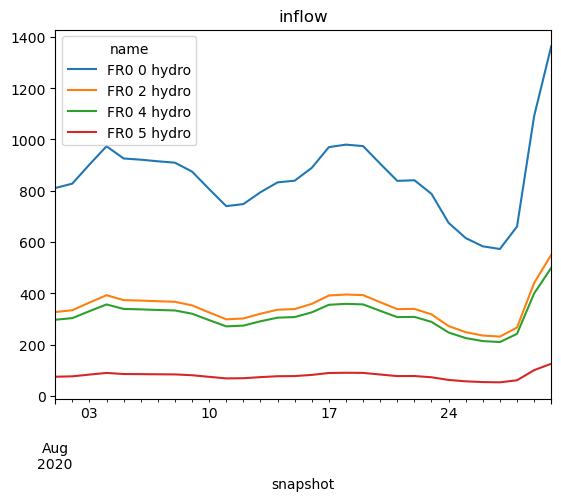


--- Time-Series for: p ---


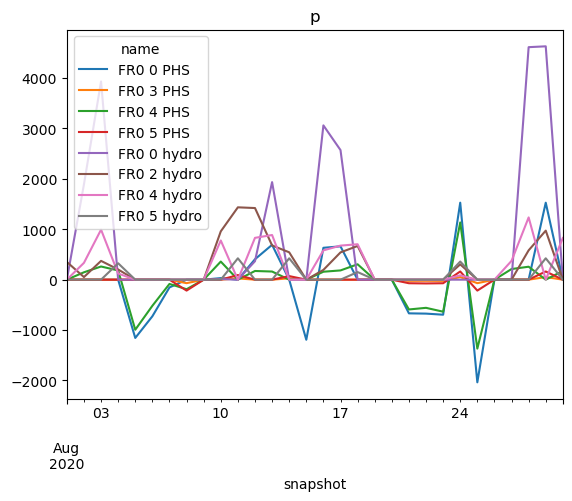


--- Time-Series for: p_dispatch ---


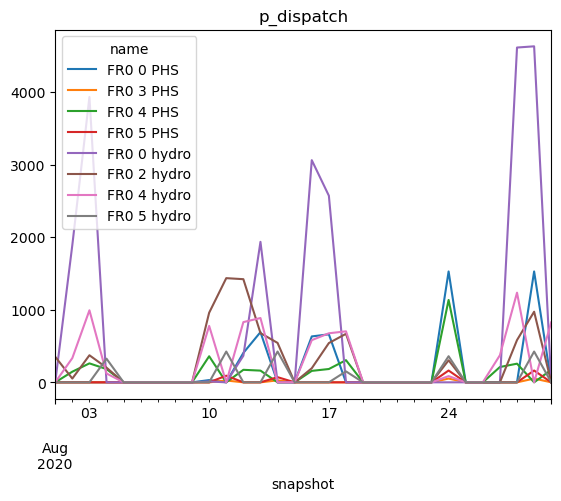


--- Time-Series for: p_store ---


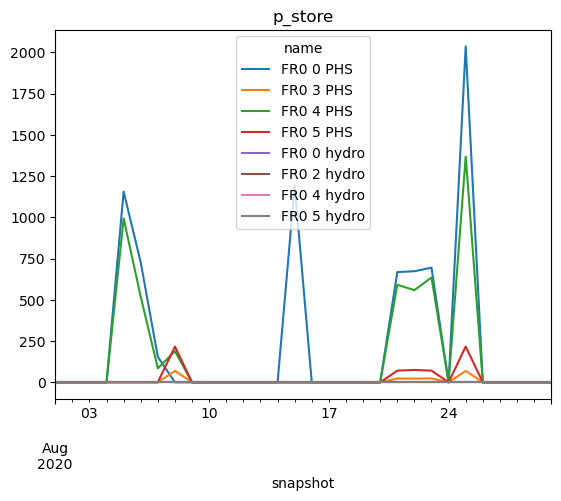

Time-Series for: q is empty or contains no data.

--- Time-Series for: state_of_charge ---


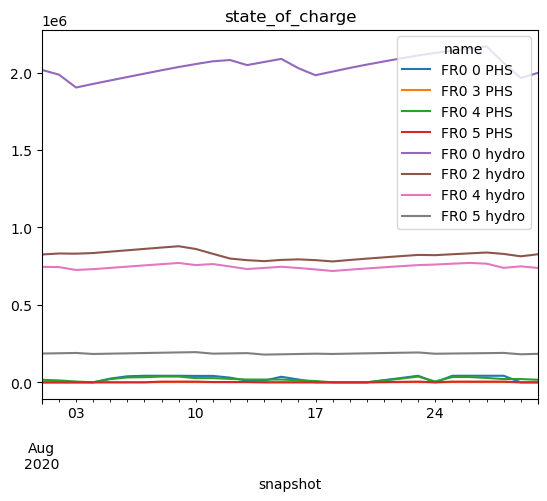


--- Time-Series for: spill ---


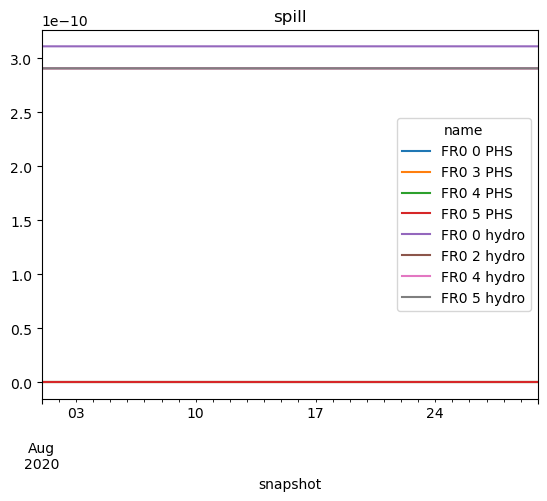

Time-Series for: mu_upper is empty or contains no data.
Time-Series for: mu_lower is empty or contains no data.
Time-Series for: mu_state_of_charge_set is empty or contains no data.
Time-Series for: mu_energy_balance is empty or contains no data.


In [108]:
# or as plots:
for key, df in n.storage_units_t.items():
    # Test if DataFrame is not empty and contains at least some non-null values
    if not df.empty and not df.isnull().all().all():
        print(f"\n--- Time-Series for: {key} ---")
        df.plot(title=key)
        plt.show()
    else:
        print(f"Time-Series for: {key} is empty or contains no data.")

Check for background of differences in dynamic data
- PHS has no inflow
- p can be negative for PHS
- p_store is 0 for hydro
- PHS has no Spill, but Spillage is ignorable tiny (Spill = Spillage, so no power Generation)

## Retrofitting "Hydro-2-PHS" Concept-1
Idea: take the static and dynamic dataframes for hydro (storage_units.carrier == "hydro" & storage_units_t.carrier == "hydro") and adjust the values to retrofitted-PHS-Configuration

**changes to static data (storage_units.carrier == "hydro")**
1. add charge capability by adjusting 
   1. **efficiency_store** from 0 to 0.866 (maybe also efficiency_dispatch from 0.9 to 0.866)
   2. **p_min_pu** from 0 to -1
2. change name
3. change carrier

**changes to the dynamic data (storage_units_t.carrier == "hydro")**  
1. keep inflow

=> no changes to dynamic data

**Try to re-optimize the system to account for changes**
=> does not account for investment costs

In [109]:
# copy hydro storage units and modify them to represent the retrofitted PHS units.
retrofitted_hydro = n.storage_units[n.storage_units.carrier == "hydro"].copy()
# implement changes
retrofitted_hydro["efficiency_store"] = 0.8666
retrofitted_hydro["p_min_pu"] = -1.0
retrofitted_hydro["carrier"] = "PHS"
retrofitted_hydro.index = retrofitted_hydro.index + "_rf"
# check if changes are implemented correctly
retrofitted_hydro.head().T

name,FR0 0 hydro_rf,FR0 2 hydro_rf,FR0 4 hydro_rf,FR0 5 hydro_rf
bus,FR0 0,FR0 2,FR0 4,FR0 5
control,PQ,PQ,PQ,PQ
type,,,,
p_nom,4629.101911,1866.196178,1694.152866,424.0
p_nom_mod,0.0,0.0,0.0,0.0
p_nom_extendable,False,False,False,False
p_nom_min,0.0,0.0,0.0,0.0
p_nom_max,inf,inf,inf,inf
p_nom_set,NaN,NaN,NaN,NaN
p_min_pu,-1.0,-1.0,-1.0,-1.0


In [112]:
# copy hydro storage units and modify them to represent the retrofitted PHS units.
#retrofitted_hydro = n.storage_units[n.storage_units.carrier == "hydro"].copy()
# implement changes
n.storage_units.loc[n.storage_units.carrier == "hydro", "efficiency_store"] = 0.8666
n.storage_units.loc[n.storage_units.carrier == "hydro", "p_min_pu"] = -1.0
n.storage_units.rename(index=lambda x: f"{x}_rf" if x in n.storage_units[n.storage_units.carrier == "hydro"].index else x, inplace=True)
#n.storage_units.loc[n.storage_units.carrier == "hydro"].index = n.storage_units.loc[n.storage_units.carrier == "hydro"].index + "_rf"
n.storage_units.loc[n.storage_units.carrier == "hydro", "carrier"] = "PHS"
# check if changes are implemented correctly
n.storage_units.T

name,FR0 0 PHS,FR0 3 PHS,FR0 4 PHS,FR0 5 PHS,FR0 0 hydro_rf,FR0 2 hydro_rf,FR0 4 hydro_rf,FR0 5 hydro_rf
bus,FR0 0,FR0 3,FR0 4,FR0 5,FR0 0,FR0 2,FR0 4,FR0 5
control,PQ,PQ,PQ,PQ,PQ,PQ,PQ,PQ
type,,,,,,,,
p_nom,3660.0,240.0,1368.0,808.0,4629.101911,1866.196178,1694.152866,424.0
p_nom_mod,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_nom_extendable,False,False,False,False,False,False,False,False
p_nom_min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_nom_max,inf,inf,inf,inf,inf,inf,inf,inf
p_nom_set,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_min_pu,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


renaming of retrofitted units time series needs to be fixed

In [113]:
n.optimize()

Index(['FR0 0 hydro', 'FR0 2 hydro', 'FR0 4 hydro', 'FR0 5 hydro'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.8s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 4341 primals, 9178 duals
Objective: 4.78e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

# Alternative: retrofit in network optimization
Idea: Give the network the option to retrofit hydro plants (if it makes sense in the optimization reducing total system costs).  

**What data/ information is needed:**
- cost of retrofitting (very important) -> Naime should have some number ~2000€/kW
- per bus, better per unit (problem: this data is not available for all plants: https://pypsa-eur.readthedocs.io/en/latest/limitations.html ==> values are country totals for most countries)
  - inflow series
  - capacity (p_nom*max_hours)